In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from PyALE import ale
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    f1_score, matthews_corrcoef, classification_report
)

RANDOM_STATE = 42
LEAKAGE_PRONE_FEATURES = ["PageValues", "BounceRates", "ExitRates"]
df = pd.read_csv("online_shoppers_intention.csv")
NOMINAL_INT_COLS = ["OperatingSystems", "Browser", "Region", "TrafficType"]
df[NOMINAL_INT_COLS] = df[NOMINAL_INT_COLS].astype("category")
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

y = df_encoded["Revenue"]

# Untouched — identical to the main analysis
X_main = df_encoded.drop("Revenue", axis=1)

# Separate copy for the sensitivity analysis only
X_early = X_main.drop(columns=LEAKAGE_PRONE_FEATURES)

print("X_main shape :", X_main.shape)
print("X_early shape:", X_early.shape)
print("Dropped columns:", LEAKAGE_PRONE_FEATURES)

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


X_main shape : (12330, 68)
X_early shape: (12330, 65)
Dropped columns: ['PageValues', 'BounceRates', 'ExitRates']


In [2]:
def fit_and_score(X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=300, min_samples_leaf=3, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1
        ),
    }

    rows = []
    for name, model in models.items():
        model.fit(X_train_s, y_train)
        y_prob = model.predict_proba(X_test_s)[:, 1]
        y_pred = model.predict(X_test_s)
        rows.append({
            "Feature set": label,
            "Model": name,
            "Accuracy": round(accuracy_score(y_test, y_pred), 4),
            "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
            "PR-AUC": round(average_precision_score(y_test, y_prob), 4),
            "F1": round(f1_score(y_test, y_pred), 4),
            "MCC": round(matthews_corrcoef(y_test, y_pred), 4),
        })
    return rows

In [3]:
results = []
results += fit_and_score(X_main, y, "Full feature set (with PageValues/BounceRates/ExitRates)")
results += fit_and_score(X_early, y, "Early-prediction (excluding PageValues/BounceRates/ExitRates)")

results_df = pd.DataFrame(results)
results_df

,Feature set,Model,Accuracy,ROC-AUC,PR-AUC,F1,MCC
0,Full feature set (with PageValues/BounceRates/...,Logistic Regression,0.8366,0.8918,0.6208,0.5832,0.5042
1,Full feature set (with PageValues/BounceRates/...,Random Forest,0.8861,0.9241,0.7221,0.6602,0.5947
2,Early-prediction (excluding PageValues/BounceR...,Logistic Regression,0.6565,0.7164,0.3088,0.3749,0.2368
3,Early-prediction (excluding PageValues/BounceR...,Random Forest,0.7976,0.7578,0.3515,0.3817,0.2616


In [4]:
summary_rows = []
for model in ["Logistic Regression", "Random Forest"]:
    full = results_df[(results_df["Model"] == model) & (results_df["Feature set"].str.startswith("Full"))].iloc[0]
    early = results_df[(results_df["Model"] == model) & (results_df["Feature set"].str.startswith("Early"))].iloc[0]
    for metric in ["Accuracy", "ROC-AUC", "PR-AUC", "F1", "MCC"]:
        summary_rows.append({
            "Model": model,
            "Metric": metric,
            "Full": full[metric],
            "Early-prediction": early[metric],
            "Delta": round(early[metric] - full[metric], 4),
            "Relative change": f"{100*(early[metric]-full[metric])/full[metric]:.1f}%"
        })

delta_df = pd.DataFrame(summary_rows)
delta_df

,Model,Metric,Full,Early-prediction,Delta,Relative change
0,Logistic Regression,Accuracy,0.8366,0.6565,-0.1801,-21.5%
1,Logistic Regression,ROC-AUC,0.8918,0.7164,-0.1754,-19.7%
2,Logistic Regression,PR-AUC,0.6208,0.3088,-0.3120,-50.3%
3,Logistic Regression,F1,0.5832,0.3749,-0.2083,-35.7%
4,Logistic Regression,MCC,0.5042,0.2368,-0.2674,-53.0%
5,Random Forest,Accuracy,0.8861,0.7976,-0.0885,-10.0%
6,Random Forest,ROC-AUC,0.9241,0.7578,-0.1663,-18.0%
7,Random Forest,PR-AUC,0.7221,0.3515,-0.3706,-51.3%
8,Random Forest,F1,0.6602,0.3817,-0.2785,-42.2%
9,Random Forest,MCC,0.5947,0.2616,-0.3331,-56.0%


In [5]:
def positive_class_shap(shap_output):
    if isinstance(shap_output, list):
        return shap_output[1] if len(shap_output) > 1 else shap_output[0]
    arr = np.asarray(shap_output)
    if arr.ndim == 3:
        return arr[:, :, 1]
    return arr

In [6]:
def rbo(list1, list2, p=0.9):
    """
    Rank-Biased Overlap (Webber, Moffat & Zobel, 2010).
    list1, list2: feature names ordered by importance (rank 1 = most important), same universe.
    p: persistence parameter — p=0.9 means the top ~10 ranks carry ~86% of the weight.
    Returns RBO in [0, 1]; 1 = identical top-weighted ordering.
    """
    s, l = (list1, list2) if len(list1) <= len(list2) else (list2, list1)
    short_len, long_len = len(s), len(l)
    if short_len == 0:
        return 0.0

    x_k = 0
    rbo_sum = 0.0
    s_set, l_set = set(), set()
    for d in range(1, long_len + 1):
        if d <= short_len:
            s_set.add(s[d - 1])
        l_set.add(l[d - 1])
        x_k = len(s_set & l_set)
        agreement_d = x_k / d
        rbo_sum += (p ** (d - 1)) * agreement_d

    rbo_ext = (1 - p) * rbo_sum
    # Extrapolation term for lists that stop at different depths
    if short_len < long_len:
        x_s = len(s_set & l_set)
        rbo_ext += (x_s * (1 - p) / short_len) * (p ** short_len) * (long_len - short_len) / long_len \
                   if short_len > 0 else 0
    return min(rbo_ext, 1.0)


In [7]:
def rbo_at_k(rank_df_a, rank_df_b, feature_col="feature", rank_col="rank",
             ks=(5, 10, None), p=0.9):
    """
    rank_df_a, rank_df_b: DataFrames with columns [feature_col, rank_col] (rank 1 = most important).
    ks: top-k cutoffs to report (None = full list).
    """
    order_a = rank_df_a.sort_values(rank_col)[feature_col].tolist()
    order_b = rank_df_b.sort_values(rank_col)[feature_col].tolist()

    rows = []
    for k in ks:
        la = order_a[:k] if k else order_a
        lb = order_b[:k] if k else order_b
        rows.append({"top_k": k if k else "all", "RBO": round(rbo(la, lb, p=p), 4), "p": p})
    return pd.DataFrame(rows)

In [8]:
# Cross-architecture RBO — top-k SHAP/coefficient ranking agreement between LR, RF, XGB
# on the chronological (Oct/Nov/Dec holdout) feature importances.
import os
RA_DIR = "Robustness Analysis"  # sibling folder holding the chronologically-tuned outputs

rf_chrono_ranking  = pd.read_csv(os.path.join(RA_DIR, "rf_chronological_shap_importance.csv"))   # cols: feature, mean_abs_shap, rank
xgb_chrono_ranking = pd.read_csv(os.path.join(RA_DIR, "xgb_chronological_shap_importance.csv"))  # cols: feature, mean_abs_shap, rank
lr_chrono_ranking  = pd.read_csv(os.path.join(RA_DIR, "lr_chronological_coefficients.csv"))      # cols: Feature, Coefficient, Odds_Ratio, Rank

# LR uses coefficient magnitude, not SHAP — rename to match rbo_at_k's expected column names
lr_chrono_ranking = lr_chrono_ranking.rename(columns={"Feature": "feature", "Rank": "rank"})

rbo_lr_rf  = rbo_at_k(lr_chrono_ranking,  rf_chrono_ranking,  ks=(5, 10, None))
rbo_rf_xgb = rbo_at_k(rf_chrono_ranking,  xgb_chrono_ranking, ks=(5, 10, None))
rbo_lr_xgb = rbo_at_k(lr_chrono_ranking,  xgb_chrono_ranking, ks=(5, 10, None))

rbo_lr_rf["Pair"]  = "LR vs RF"
rbo_rf_xgb["Pair"] = "RF vs XGB"
rbo_lr_xgb["Pair"] = "LR vs XGB"

cross_model_rbo = pd.concat([rbo_lr_rf, rbo_rf_xgb, rbo_lr_xgb], ignore_index=True)
cross_model_rbo.to_csv("cross_model_rbo.csv", index=False)
cross_model_rbo


,top_k,RBO,p,Pair
0,5,0.0000,0.9,LR vs RF
1,10,0.0000,0.9,LR vs RF
2,all,0.1262,0.9,LR vs RF
3,5,0.3964,0.9,RF vs XGB
4,10,0.6100,0.9,RF vs XGB
5,all,0.9270,0.9,RF vs XGB
6,5,0.0000,0.9,LR vs XGB
7,10,0.0222,0.9,LR vs XGB
8,all,0.1507,0.9,LR vs XGB


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_early, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

rf_early = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=3, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_early.fit(X_train_s, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
def positive_class_shap(shap_output):
    if isinstance(shap_output, list):
        return shap_output[1] if len(shap_output) > 1 else shap_output[0]
    arr = np.asarray(shap_output)
    if arr.ndim == 3:
        return arr[:, :, 1]
    return arr

explainer = shap.TreeExplainer(rf_early, feature_perturbation="tree_path_dependent")
sv = positive_class_shap(explainer.shap_values(X_test_s, check_additivity=False))

importance_early = pd.DataFrame({
    "feature": X_early.columns,
    "mean_abs_shap": np.abs(sv).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
importance_early["rank"] = importance_early.index + 1
importance_early.to_csv("shap_importance_table_rf_early.csv", index=False)
print(importance_early.head(10))

# X_test_s_df defined here so both this plot and the ALE cell below use it consistently
X_test_s_df = pd.DataFrame(X_test_s, columns=X_early.columns)

shap.summary_plot(sv, X_test_s_df, show=False)   # was X_test (raw) — now matches the scaled inputs sv was computed on
plt.tight_layout()
plt.savefig("shap_beeswarm_early.png", dpi=200)
plt.close('all')

                         feature  mean_abs_shap  rank
0        ProductRelated_Duration       0.062849     1
1                      Month_Nov       0.038469     2
2                 ProductRelated       0.036073     3
3        Administrative_Duration       0.032537     4
4                  TrafficType_2       0.028965     5
5  VisitorType_Returning_Visitor       0.027646     6
6                 Administrative       0.026976     7
7             OperatingSystems_2       0.012714     8
8                     SpecialDay       0.012374     9
9             OperatingSystems_3       0.012100    10


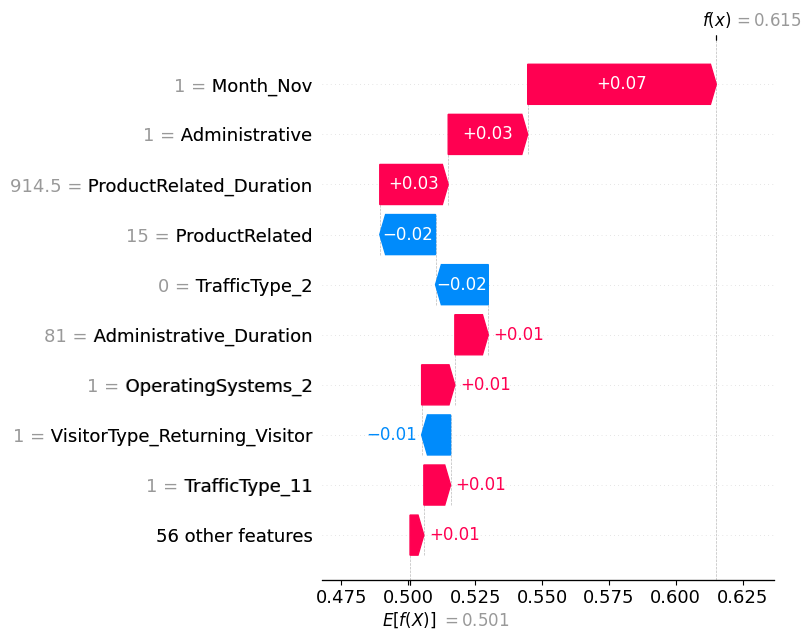

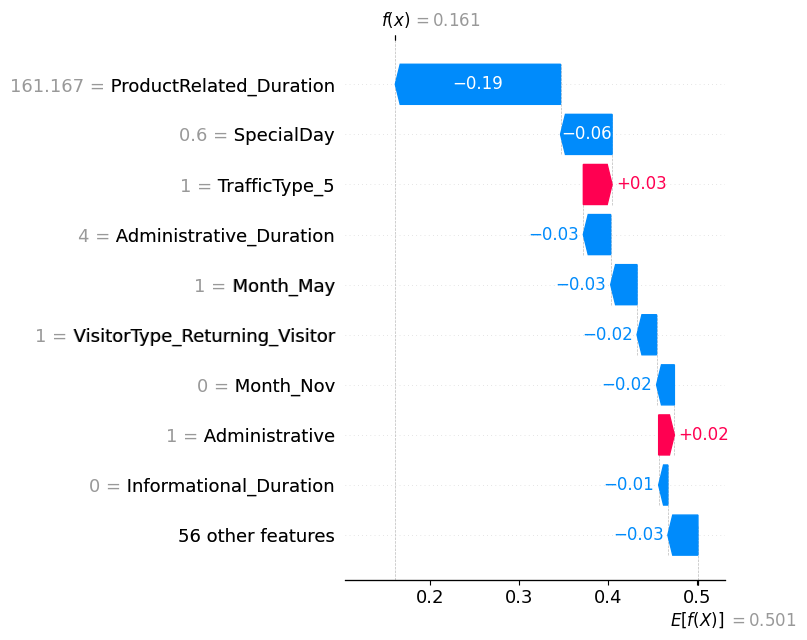

Purchase session — base value: 0.5006
Purchase session — top feature: Month_Nov SHAP = 0.0705
Non-purchase session — top feature: ProductRelated_Duration SHAP = -0.1854


In [11]:
# Waterfall plots — Random Forest, leakage-free feature set
# X_test (raw, unscaled) already exists from the train_test_split cell above rf_early's training —
# used here purely for readable feature values on the axis (not for prediction)

y_pred_early = rf_early.predict(X_test_s)

purchase_pos = np.where((y_test.values == 1) & (y_pred_early == 1))[0][0]
no_purchase_pos = np.where((y_test.values == 0) & (y_pred_early == 0))[0][0]

base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[1]  # positive-class base value

# Correctly classified purchasing session
explanation_purchase = shap.Explanation(
    values=sv[purchase_pos],
    base_values=base_value,
    data=X_test.iloc[purchase_pos].values,
    feature_names=list(X_early.columns)
)
shap.plots.waterfall(explanation_purchase, show=False)
plt.tight_layout()
plt.savefig("waterfall_rf_early_purchase.png", dpi=200, bbox_inches="tight")
plt.show()

# Correctly classified non-purchasing session
explanation_no_purchase = shap.Explanation(
    values=sv[no_purchase_pos],
    base_values=base_value,
    data=X_test.iloc[no_purchase_pos].values,
    feature_names=list(X_early.columns)
)
shap.plots.waterfall(explanation_no_purchase, show=False)
plt.tight_layout()
plt.savefig("waterfall_rf_early_no_purchase.png", dpi=200, bbox_inches="tight")
plt.show()

print("Purchase session — base value:", round(base_value, 4))
print("Purchase session — top feature:", X_early.columns[np.argmax(np.abs(sv[purchase_pos]))],
      "SHAP =", round(sv[purchase_pos][np.argmax(np.abs(sv[purchase_pos]))], 4))
print("Non-purchase session — top feature:", X_early.columns[np.argmax(np.abs(sv[no_purchase_pos]))],
      "SHAP =", round(sv[no_purchase_pos][np.argmax(np.abs(sv[no_purchase_pos]))], 4))

In [12]:
results_df.to_csv("leakage_ablation_results.csv", index=False)
delta_df.to_csv("leakage_ablation_delta.csv", index=False)
print("Saved: leakage_ablation_results.csv, leakage_ablation_delta.csv")
print("Original main-analysis files (X_test_raw.csv, shopping_model.pkl, shopping_model_rf.pkl, etc.) were not touched.")

Saved: leakage_ablation_results.csv, leakage_ablation_delta.csv
Original main-analysis files (X_test_raw.csv, shopping_model.pkl, shopping_model_rf.pkl, etc.) were not touched.


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


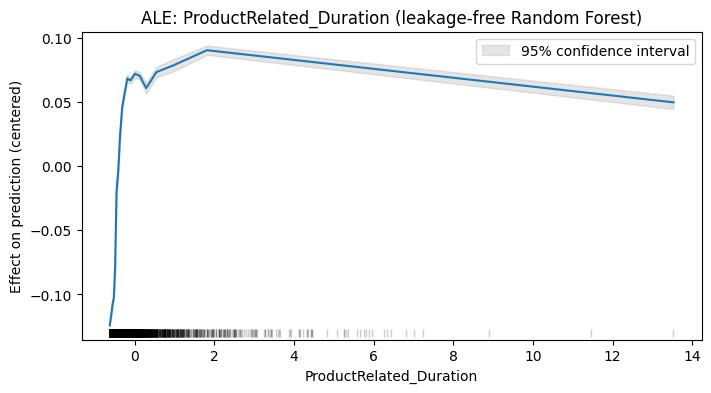

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


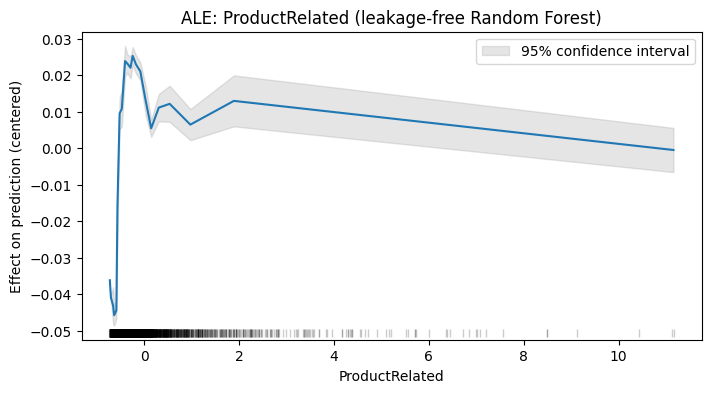

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


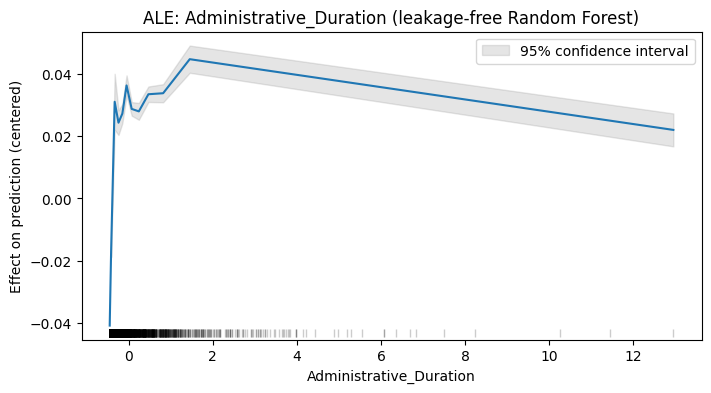

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


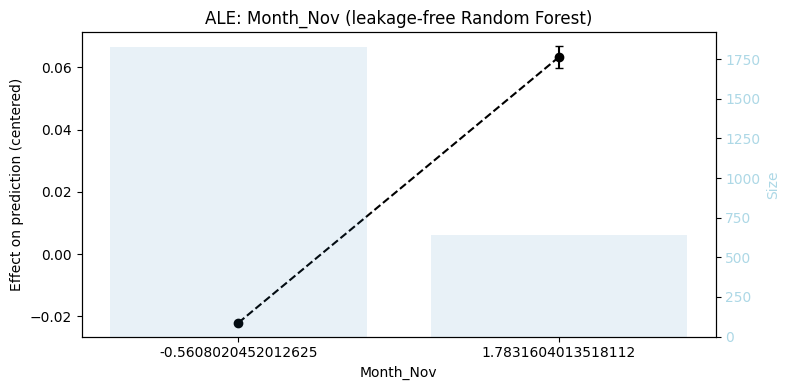

In [13]:
class ProbaWrapper:
    def __init__(self, fitted_model):
        self.model = fitted_model
    def predict(self, X):
        return self.model.predict_proba(X)[:, 1]

rf_wrapped = ProbaWrapper(rf_early)

ale_features = [
    ("ProductRelated_Duration", "continuous"),
    ("ProductRelated", "continuous"),
    ("Administrative_Duration", "continuous"),
    ("Month_Nov", "discrete"),
]
for feat, ftype in ale_features:
    ale_eff = ale(X=X_test_s_df, model=rf_wrapped, feature=[feat],
                   feature_type=ftype, grid_size=20, include_CI=True)
    plt.title(f"ALE: {feat} (leakage-free Random Forest)")
    plt.savefig(f"ale_{feat}.png", dpi=200, bbox_inches="tight")
    plt.show()

In [14]:
probs = rf_early.predict_proba(X_test_s)[:, 1]
non_purchase_idx = np.where(y_test.values == 0)[0]
near_threshold_idx = non_purchase_idx[np.argmin(np.abs(probs[non_purchase_idx] - 0.5))]

original_prob = probs[near_threshold_idx]

target_feature = "ProductRelated_Duration"
target_col = list(X_early.columns).index(target_feature)
median_target_scaled = np.median(X_train_s[:, target_col])

X_cf = X_test_s[near_threshold_idx].copy().reshape(1, -1)
X_cf[0, target_col] = median_target_scaled

cf_prob = rf_early.predict_proba(X_cf)[0, 1]

print(f"Original predicted probability: {original_prob:.3f}")
print(f"Counterfactual predicted probability ({target_feature} -> median): {cf_prob:.3f}")
print(f"Original {target_feature} (scaled): {X_test_s[near_threshold_idx, target_col]:.3f}")
print(f"Median {target_feature} (scaled): {median_target_scaled:.3f}")

Original predicted probability: 0.500
Counterfactual predicted probability (ProductRelated_Duration -> median): 0.442
Original ProductRelated_Duration (scaled): 0.935
Median ProductRelated_Duration (scaled): -0.307


In [15]:
# --- Predictive multiplicity: Ambiguity & Discrepancy across the Rashomon set ---
# Rashomon set = models with holdout accuracy within epsilon of the best model.
# Definitions follow Marx, Calmon & Ustun (2020) / Black, Raghavan & Barocas (2022).
import os
import joblib

RA_DIR = "Robustness Analysis"  # sibling folder holding the chronologically-tuned models/scalers

# Rebuild the same chronological (Oct/Nov/Dec) holdout used by the three robustness notebooks.
TEST_MONTHS = ["Oct", "Nov", "Dec"]
test_mask = df["Month"].isin(TEST_MONTHS)

# RF_Robustness and XGBoost_Robustness train on the leakage-ablated feature set (X_early);
# Logistic Regression_R trains on the full feature set (X_main). Each model must be fed
# the feature representation it was actually trained on -- Ambiguity/Discrepancy only
# require the same underlying test *sessions*, not the same column representation.
X_test_chrono_full  = X_main[test_mask]   # for LR      (68 cols)
X_test_chrono_early = X_early[test_mask]  # for RF/XGB  (65 cols)
y_test_chrono = y[test_mask]

# Load each model together with its own fitted scaler.
lr_c  = joblib.load(os.path.join(RA_DIR, "shopping_model_lr_chronological.pkl"))
rf_c  = joblib.load(os.path.join(RA_DIR, "shopping_model_rf_chronological.pkl"))
xgb_c = joblib.load(os.path.join(RA_DIR, "shopping_model_xgb_chronological.pkl"))

scaler_lr  = joblib.load(os.path.join(RA_DIR, "shopping_scaler_lr_chronological.pkl"))
scaler_rf  = joblib.load(os.path.join(RA_DIR, "shopping_scaler_rf_chronological.pkl"))
scaler_xgb = joblib.load(os.path.join(RA_DIR, "shopping_scaler_xgb_chronological.pkl"))

# Sanity check -- catches a stale/un-re-run .pkl immediately instead of a confusing
# downstream shape-mismatch error deep inside sklearn.
assert lr_c.n_features_in_ == X_test_chrono_full.shape[1], (
    f"LR model expects {lr_c.n_features_in_} features, X_test_chrono_full has "
    f"{X_test_chrono_full.shape[1]} -- check Logistic Regression_R.ipynb was re-run after Fix 1."
)
assert rf_c.n_features_in_ == X_test_chrono_early.shape[1], (
    f"RF model expects {rf_c.n_features_in_} features, X_test_chrono_early has "
    f"{X_test_chrono_early.shape[1]} -- re-run RandomForest_Robustness.ipynb's final "
    "joblib.dump cell (this is the stale pre-Fix-1 artifact)."
)
assert xgb_c.n_features_in_ == X_test_chrono_early.shape[1], (
    f"XGB model expects {xgb_c.n_features_in_} features, X_test_chrono_early has "
    f"{X_test_chrono_early.shape[1]} -- check XGBoost_Robustness.ipynb was re-run after Fix 1."
)

preds = {
    "LR":  lr_c.predict(scaler_lr.transform(X_test_chrono_full)),
    "RF":  rf_c.predict(scaler_rf.transform(X_test_chrono_early)),
    "XGB": xgb_c.predict(scaler_xgb.transform(X_test_chrono_early)),
}
accs = {name: accuracy_score(y_test_chrono, p) for name, p in preds.items()}
accs


{'LR': 0.8168373151308305, 'RF': 0.6808873720136519, 'XGB': 0.5491088357982556}

In [16]:
best_acc = max(accs.values())
EPSILON = 0.01  # 1 percentage point -- state this choice explicitly in the manuscript
rashomon_set = {n: p for n, p in preds.items() if accs[n] >= best_acc - EPSILON}

reference_model = max(accs, key=accs.get)
ref_preds = preds[reference_model]

# Ambiguity: fraction of test points where >=1 Rashomon model disagrees with reference
disagree_mask = np.zeros(len(ref_preds), dtype=bool)
for n, p in rashomon_set.items():
    if n == reference_model:
        continue
    disagree_mask |= (p != ref_preds)
ambiguity = disagree_mask.mean()

# Discrepancy: worst-case pairwise disagreement rate within the Rashomon set
max_discrepancy = 0.0
names = list(rashomon_set.keys())
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        d = (rashomon_set[names[i]] != rashomon_set[names[j]]).mean()
        max_discrepancy = max(max_discrepancy, d)

multiplicity_summary = pd.DataFrame([{
    "Rashomon_set": ", ".join(rashomon_set.keys()),
    "Epsilon": EPSILON,
    "Reference_model": reference_model,
    "Ambiguity": ambiguity,
    "Discrepancy": max_discrepancy,
    **{f"Accuracy_{n}": round(a, 4) for n, a in accs.items()},
}])
multiplicity_summary.to_csv("predictive_multiplicity_summary.csv", index=False)
multiplicity_summary


,Rashomon_set,Epsilon,Reference_model,Ambiguity,Discrepancy,Accuracy_LR,Accuracy_RF,Accuracy_XGB
0,LR,0.01,LR,0.0,0.0,0.8168,0.6809,0.5491
